Grid size: 10x10 | NumPy time: 0.0998s | Torch GPU time: 0.0430s
Grid size: 50x50 | NumPy time: 1.9666s | Torch GPU time: 0.0516s
Grid size: 100x100 | NumPy time: 9.0540s | Torch GPU time: 0.0756s
Grid size: 200x200 | NumPy time: 35.3836s | Torch GPU time: 0.3941s
Grid size: 300x300 | NumPy time: 81.0835s | Torch GPU time: 0.7021s


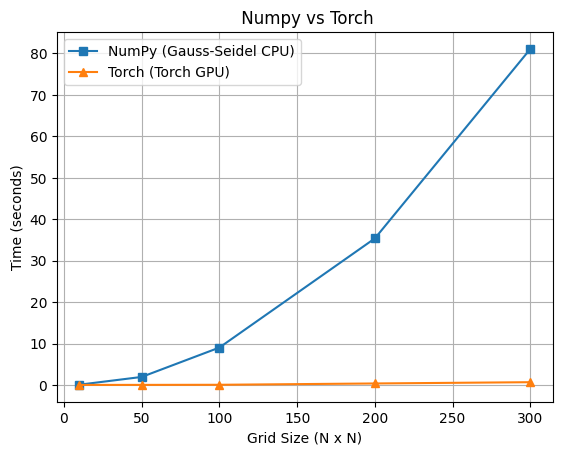

In [13]:

import numpy as np
import matplotlib.pyplot as plt
from timeit import default_timer as timer
import torch

def gauss_seidel(f):

    newf = f.copy()
    for i in range(1, newf.shape[0] - 1):
        for j in range(1, newf.shape[0] - 1):
            newf[i,j] = 0.25 * (newf[i,j+1] + newf[i, j-1]+
                                newf[i+1,j] + newf[i-1,j])

    return newf


def gauss_seidel_torch(f):
    newf = f.clone()

    newf = 0.25 * (torch.roll(f, shifts=1, dims=0)+
                       torch.roll(f, shifts=-1, dims=0)+
                       torch.roll(f, shifts=1, dims=1)+
                       torch.roll(f,shifts=-1, dims=1))



    return newf




def initialize(grid_sizes):
    times_numpy = []
    times_torch = []

    for N in grid_sizes:
        f_numpy = np.random.rand(N, N).astype(np.float64)
        f_numpy[0, :] = f_numpy[-1, :] = f_numpy[:, 0] = f_numpy[:, -1] = 0  # Boundary conditions
        f_torch = torch.tensor(f_numpy, dtype=torch.float64)


        start_time = timer()
        for _ in range(1000):
            f_numpy = gauss_seidel(f_numpy)
        end_time = timer()
        times_numpy.append(end_time - start_time)


        start_time = timer()
        for _ in range(1000):
            f_torch = gauss_seidel_torch(f_torch)
        end_time = timer()
        times_torch.append(end_time - start_time)

        print(f"Grid size: {N}x{N} | NumPy time: {times_numpy[-1]:.4f}s | Torch GPU time: {times_torch[-1]:.4f}s")

    return times_numpy, times_torch


if __name__ == "__main__":
    grid_sizes = [10, 50, 100, 200, 300]
    times_numpy, times_torch = initialize(grid_sizes)


    plt.plot(grid_sizes, times_numpy, marker='s', linestyle='-', label='NumPy (Gauss-Seidel CPU)')
    plt.plot(grid_sizes, times_torch, marker='^', linestyle='-', label='Torch (Torch GPU)')
    plt.xlabel('Grid Size (N x N)')
    plt.ylabel('Time (seconds)')
    plt.title(' Numpy vs Torch')
    plt.legend()
    plt.grid()
    plt.show()





